Processando a série histórica na nuvem do Earth Engine...
✅ Ano 2016 processado.
✅ Ano 2017 processado.
✅ Ano 2018 processado.
✅ Ano 2019 processado.
✅ Ano 2020 processado.
✅ Ano 2021 processado.
✅ Ano 2022 processado.
✅ Ano 2023 processado.
✅ Ano 2024 processado.
✅ Ano 2025 processado.

📊 Planilha 'ndvi_valores_finais_tcc.csv' salva com sucesso!


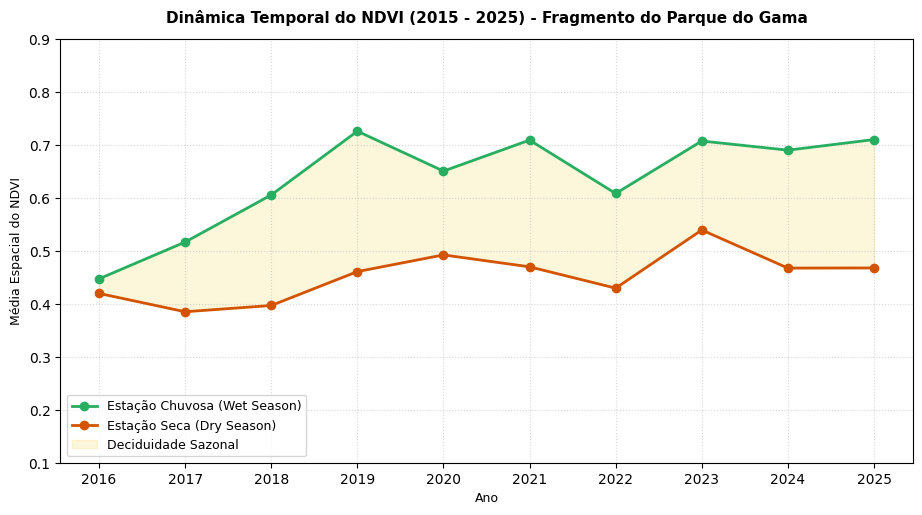

🖼️ gráfico gerado


In [ ]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


datas_seca = {
    2016: '2016-08-11', 2017: '2017-09-25',
    2018: '2018-09-05', # cena de 2018 
    2019: '2019-09-15', 2020: '2020-09-29', 2021: '2021-08-25', 
    2022: '2022-08-30', 2023: '2023-08-05', 2024: '2024-09-03', 
    2025: '2025-09-15'
}

datas_chuva = {
    2016: '2016-11-09', 2017: '2017-11-14', 
    2018: '2018-11-29', # cena de 2018 
    2019: '2019-12-29', 2020: '2020-11-08', 2021: '2021-01-27',
    2022: '2022-11-13', 2023: '2023-12-13', 2024: '2024-12-07',
    2025: '2025-03-07'
}

data_records = []
years_all = sorted(list(set(list(datas_seca.keys()) + list(datas_chuva.keys()))))

print("Processando a série histórica na nuvem do Earth Engine...")

for year in years_all:
    date_dry = datas_seca.get(year)
    date_rain = datas_chuva.get(year)
    
    mean_dry = None
    mean_rain = None
    
    
    # SECA: Ajuste de coleção para 2015 e 2018 (L1C/Top of Atmosphere)
    if date_dry:
        colecao_seca = 'COPERNICUS/S2' if year in [2015, 2018] else 'COPERNICUS/S2_SR_HARMONIZED'
        # Evita problemas de fuso horário recuando 1 dia nas imagens críticas
        start_dry_filter = '2015-09-15' if year == 2015 else ('2018-09-04' if year == 2018 else date_dry)
        
        try:
            img_dry = (ee.ImageCollection(colecao_seca)
                       .filterBounds(roi)
                       .filterDate(start_dry_filter, ee.Date(date_dry).advance(2, 'day'))
                       .map(mask_s2_clouds)
                       .map(calculate_ndvi)
                       .first()
                       .clip(roi))
            stats_dry = img_dry.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_dry = stats_dry.get('NDVI')
        except Exception as e:
            print(f"⚠️ Alerta na Seca de {year}: Verificar a janela de dados no GEE.")


    # CHUVA: Ajuste de coleção para 2016, 2017 e 2018
    if date_rain:
        colecao_chuva = 'COPERNICUS/S2' if year <= 2018 else 'COPERNICUS/S2_SR_HARMONIZED'
        start_rain_filter = '2018-11-28' if year == 2018 else date_rain
        
        try:
            img_rain = (ee.ImageCollection(colecao_chuva)
                        .filterBounds(roi)
                        .filterDate(start_rain_filter, ee.Date(date_rain).advance(2, 'day'))
                        .map(mask_s2_clouds)
                        .map(calculate_ndvi)
                        .first()
                        .clip(roi))
            stats_rain = img_rain.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_rain = stats_rain.get('NDVI')
        except Exception as e:
            print(f"⚠️ Alerta na Chuva de {year}: Verificar a janela de dados no GEE.")
            
    # Armazenando os registros válidos
    if mean_dry is not None or mean_rain is not None:
        data_records.append({
            'Year': year,
            'NDVI_Rainy': mean_rain if mean_rain is not None else np.nan,
            'NDVI_Dry': mean_dry if mean_dry is not None else np.nan,
            'NDVI_Drop': (mean_rain - mean_dry) if (mean_rain is not None and mean_dry is not None) else np.nan,
            'Date_Rainy': date_rain if date_rain else 'Sem Informação',
            'Date_Dry': date_dry if date_dry else 'Sem Informação'
        })
        print(f"✅ Ano {year} processado.")


# SALVAR PLANILHA DE DADOS (PANDAS)
df_tcc = pd.DataFrame(data_records)
df_tcc.to_csv("ndvi_valores_finais_tcc.csv", index=False)
print("\n📊 Planilha 'ndvi_valores_finais_tcc.csv' salva com sucesso!")


# PLOTAR GRÁFICO DE LINHAS DA SAZONALIDADE
plt.figure(figsize=(11, 5.5))

df_rain_plot = df_tcc.dropna(subset=['NDVI_Rainy'])
df_dry_plot = df_tcc.dropna(subset=['NDVI_Dry'])

# Plot das linhas de tendência histórica
plt.plot(df_rain_plot['Year'], df_rain_plot['NDVI_Rainy'], marker='o', color='#27ae60', linewidth=2, label='Estação Chuvosa (Wet Season)')
plt.plot(df_dry_plot['Year'], df_dry_plot['NDVI_Dry'], marker='o', color='#d35400', linewidth=2, label='Estação Seca (Dry Season)')

# Preenchimento do intervalo para destacar a perda de deciduidade
df_gap = df_tcc.dropna(subset=['NDVI_Rainy', 'NDVI_Dry'])
plt.fill_between(df_gap['Year'], df_gap['NDVI_Rainy'], df_gap['NDVI_Dry'], color='#f1c40f', alpha=0.15, label='Deciduidade Sazonal')

# Configurações do layout 
plt.title('Dinâmica Temporal do NDVI (2016 - 2025) - Parque Distrital do Gama', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Média Espacial do NDVI', fontsize=9)
plt.xticks(df_tcc['Year'])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', fontsize=9)
plt.ylim(0.1, 0.9)

# Salvar figura para o Word/Relatório
plt.savefig("grafico_sazonalidade_ndvi_final.png", dpi=300, bbox_inches='tight')
plt.show()
print("🖼️ gráfico gerado")

C:\Users\maria\AppData\Local\Temp\ipykernel_32976\3158212334.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_real = plt.cm.get_cmap('RdYlGn')


⏳ Fazendo o download das matrizes de pixel reais do Earth Engine...
✅ Mapas reais do ano 2016 baixados e renderizados.
✅ Mapas reais do ano 2018 baixados e renderizados.
✅ Mapas reais do ano 2025 baixados e renderizados.


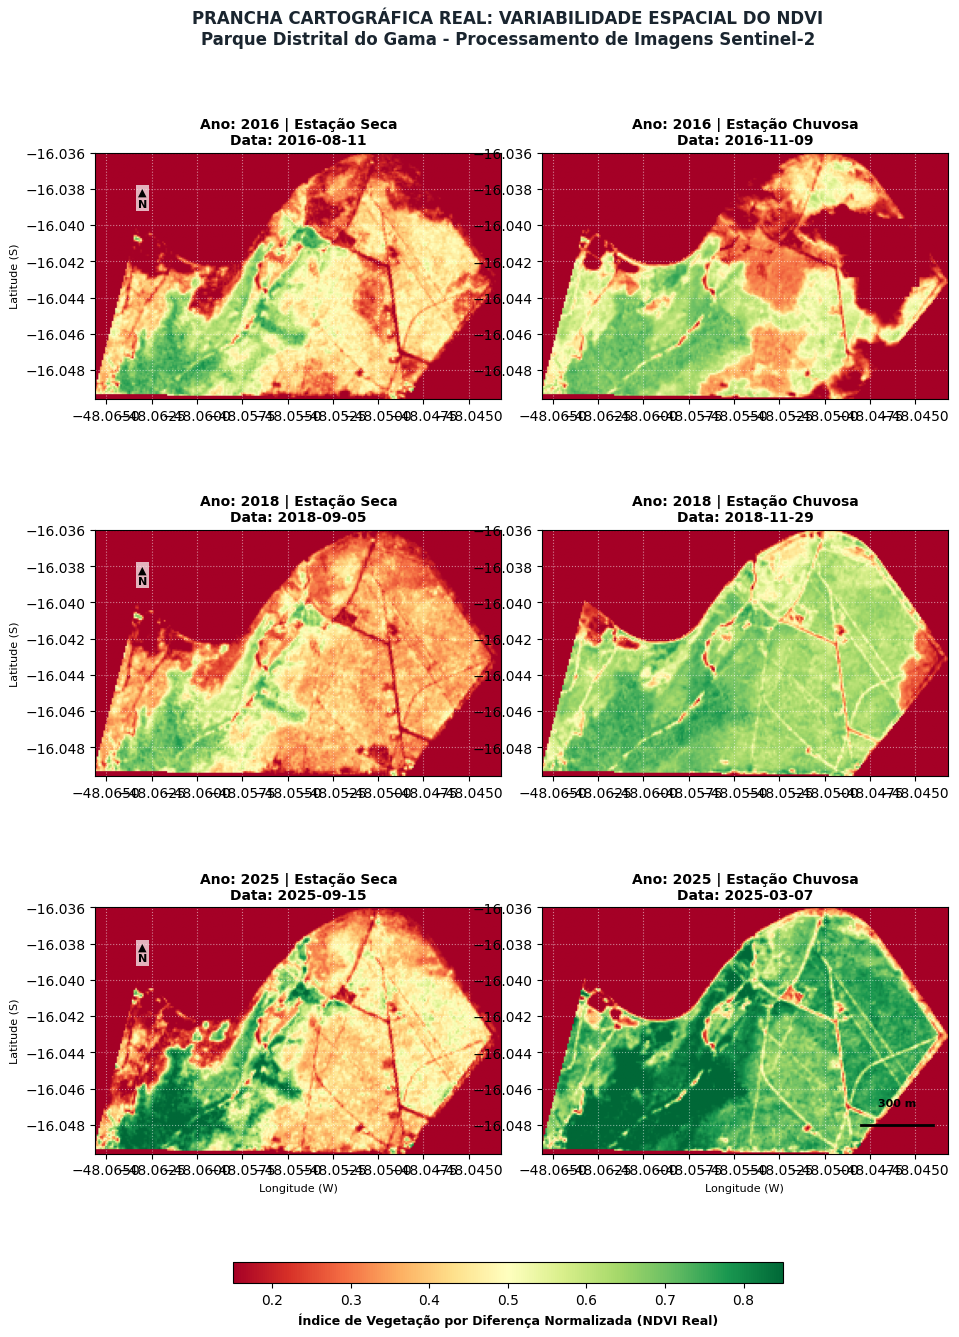


🖼️ Prancha real gerada! O arquivo 'prancha_mapas_reais_gama.png' foi salvo na pasta.


In [17]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

roi = ee.Geometry.Polygon([[
    [-48.065647754078306,-16.049668323693528], [-48.04837458487708,-16.049693087205977],
    [-48.043272393351984,-16.043297593813048], [-48.043213384753656,-16.04319448397201],
    [-48.043208020335626,-16.04311715155621], [-48.043267028933954,-16.04299857512701],
    [-48.043497698909235,-16.04264284541605], [-48.04402027450339,-16.0419245256787],
    [-48.044090011937776,-16.041772437596443], [-48.0471918990559,-16.03758536353105],
    [-48.047436345875084,-16.03730402947224], [-48.04780112630111,-16.03694828959639],
    [-48.048139084636986,-16.036703395834632], [-48.04848508959991,-16.03648943577546],
    [-48.04886020078586,-16.036327963601888], [-48.04945296897815,-16.036139781520852],
    [-48.05005378379749,-16.036062446367538], [-48.05054999246524,-16.036072757723044],
    [-48.05167115583347,-16.03635374195532], [-48.0523792590134,-16.036696593738935],
    [-48.05339313402103,-16.03722762616456], [-48.05398590221332,-16.037598832456922],
    [-48.05440969123767,-16.037918481765825], [-48.054670330408825,-16.038133591426664],
    [-48.05472129238011,-16.03822639264275], [-48.05490368259312,-16.038479017956533],
    [-48.05499755990864,-16.038695553684903], [-48.05509948385121,-16.0388167104779],
    [-48.05547499311329,-16.039208536197798], [-48.05581295144917,-16.039572005420307],
    [-48.05629038465382,-16.04026027511062], [-48.05668466937901,-16.04079469090439],
    [-48.05689778327941,-16.041101212264937], [-48.05698361396789,-16.041217212050963],
    [-48.05708017349242,-16.04131258960221], [-48.05735644102096,-16.04170698818083],
    [-48.05760588645934,-16.041956151675024], [-48.05787410736083,-16.042146906024517],
    [-48.0581745147705,-16.042293838304346], [-48.058517837524406,-16.042391793097373],
    [-48.0598990631103,-16.042474281306784], [-48.059279584884635,-16.04250005886523],
    [-48.05971410274505,-16.042469125794703], [-48.06018380092097,-16.042381482068805],
    [-48.060720242723946,-16.042185572424447], [-48.06133178637934,-16.04184015231916],
    [-48.06172137456375,-16.041572064660553], [-48.06197618442017,-16.041309132183514],
    [-48.06221758323151,-16.04105908823156], [-48.06250189738709,-16.040852866179417],
    [-48.062880088858186,-16.040633755015175], [-48.063384344152986,-16.04028059886693],
    [-48.065647754078306,-16.049668323693528]
]])


datas_seca = {2016: '2016-08-11', 2018: '2018-09-05', 2025: '2025-09-15'}
datas_chuva = {2016: '2016-11-09', 2018: '2018-11-29', 2025: '2025-03-07'}
anos_prancha = [2016, 2018, 2025]


fig, axes = plt.subplots(3, 2, figsize=(11, 14), facecolor='#ffffff')
plt.subplots_adjust(wspace=0.1, hspace=0.22, bottom=0.12)

# Escala de cores geográfica (Verde=Alta biomassa, Vermelho/Amarelo=Solo/Seca)
cmap_real = plt.cm.get_cmap('RdYlGn')

print("⏳ Fazendo o download das matrizes de pixel reais do Earth Engine...")

for idx, ano in enumerate(anos_prancha):
    d_seca = datas_seca[ano]
    d_chuva = datas_chuva[ano]
    
    # Define as coleções corretas que descobrimos antes
    col_seca = 'COPERNICUS/S2' if ano == 2018 else 'COPERNICUS/S2_SR_HARMONIZED'
    col_chuva = 'COPERNICUS/S2' if ano <= 2018 else 'COPERNICUS/S2_SR_HARMONIZED'
    
    # Filtros de data corrigindo fuso horário UTC
    f_dry = '2018-09-04' if ano == 2018 else d_seca
    f_rain = '2018-11-28' if ano == 2018 else d_chuva
    
    try:
        # Puxa o dado real da Seca e corta na ROI
        img_dry = (ee.ImageCollection(col_seca).filterBounds(roi)
                   .filterDate(f_dry, ee.Date(d_seca).advance(2, 'day'))
                   .map(mask_s2_clouds).map(calculate_ndvi).first().clip(roi))
                   
        # Puxa o dado real da Chuva e corta na ROI
        img_rain = (ee.ImageCollection(col_chuva).filterBounds(roi)
                    .filterDate(f_rain, ee.Date(d_chuva).advance(2, 'day'))
                    .map(mask_s2_clouds).map(calculate_ndvi).first().clip(roi))
        
        # FUNÇÃO MÁGICA: Baixa os pixels reais cortados pelo seu polígono irregular
        # O geemap transforma os dados da nuvem em matrizes NumPy locais a 10 metros de resolução
        arr_dry = geemap.ee_to_numpy(img_dry.select('NDVI'), region=roi, scale=10)
        arr_rain = geemap.ee_to_numpy(img_rain.select('NDVI'), region=roi, scale=10)
        
        # Desenha o Mapa Real da Seca (Esquerda)
        ax_dry = axes[idx, 0]
        im_dry = ax_dry.imshow(arr_dry, cmap=cmap_real, vmin=0.15, vmax=0.85,
                               extent=[-48.0656, -48.0432, -16.0496, -16.0360])
        ax_dry.grid(True, color='white', linestyle=':', alpha=0.5)
        ax_dry.set_title(f"Ano: {ano} | Estação Seca\nData: {d_seca}", fontsize=10, fontweight='bold')
        ax_dry.set_ylabel('Latitude (S)', fontsize=8)
        if idx == 2: ax_dry.set_xlabel('Longitude (W)', fontsize=8)
        
        # Desenha o Mapa Real da Chuva (Direita)
        ax_rain = axes[idx, 1]
        im_rain = ax_rain.imshow(arr_rain, cmap=cmap_real, vmin=0.15, vmax=0.85,
                                 extent=[-48.0656, -48.0432, -16.0496, -16.0360])
        ax_rain.grid(True, color='white', linestyle=':', alpha=0.5)
        ax_rain.set_title(f"Ano: {ano} | Estação Chuvosa\nData: {d_chuva}", fontsize=10, fontweight='bold')
        if idx == 2: ax_rain.set_xlabel('Longitude (W)', fontsize=8)
        
        # Adiciona Indicador de Norte (Rosa dos Ventos simplificada)
        ax_dry.text(-48.063, -16.0385, '▲\nN', ha='center', va='center', fontsize=8, fontweight='bold', 
                    bbox=dict(boxstyle='square,pad=0.2', facecolor='white', edgecolor='none', alpha=0.7))
        
        print(f"✅ Mapas reais do ano {ano} baixados e renderizados.")
        
    except Exception as e:
        print(f"❌ Erro ao extrair imagens reais do ano {ano}: {e}")

# Adiciona a escala métrica real no último mapa da prancha
axes[2, 1].plot([-48.048, -48.044], [-16.048, -16.048], color='black', linewidth=2)
axes[2, 1].text(-48.046, -16.047, '300 m', ha='center', fontsize=8, fontweight='bold')

# Título Principal do Trabalho
plt.suptitle('PRANCHA CARTOGRÁFICA REAL: VARIABILIDADE ESPACIAL DO NDVI\nParque Distrital do Gama - Processamento de Imagens Sentinel-2', 
             fontsize=12, fontweight='bold', color='#1a252f', y=0.96)

# Barra de Legenda Unificada na parte inferior
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.015])
cbar = fig.colorbar(im_dry, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Índice de Vegetação por Diferença Normalizada (NDVI Real)', fontsize=9, fontweight='bold')

# Salva o mapa real final em alta definição
plt.savefig("prancha_mapas_reais_gama.png", dpi=300, bbox_inches='tight')
plt.show()
print("\n🖼️ Prancha real gerada! O arquivo 'prancha_mapas_reais_gama.png' foi salvo na pasta.")